In [1]:
# ============================================================
# Imports
# ============================================================

from pathlib import Path
import json

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.fft import fft, fftfreq

from IPython.display import display

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

print("Libraries Imported Successfully.")

Libraries Imported Successfully.


In [2]:
# ============================================================
# Project Setup
# ============================================================

PROJECT_ROOT = Path.cwd().parent

DATA_ROOT = PROJECT_ROOT / "data" / "raw"

HAR_PATH = DATA_ROOT / "artifacts" / "har"

COUGH_PATH = DATA_ROOT / "artifacts" / "cough_imu"

print("=" * 60)
print("PROJECT INFORMATION")
print("=" * 60)

print(f"Project Root : {PROJECT_ROOT}")
print(f"Data Root    : {DATA_ROOT}")
print(f"HAR Dataset  : {HAR_PATH}")
print(f"Cough Dataset: {COUGH_PATH}")

PROJECT INFORMATION
Project Root : c:\Users\Asus\OneDrive\Desktop\fetal_assesment_project
Data Root    : c:\Users\Asus\OneDrive\Desktop\fetal_assesment_project\data\raw
HAR Dataset  : c:\Users\Asus\OneDrive\Desktop\fetal_assesment_project\data\raw\artifacts\har
Cough Dataset: c:\Users\Asus\OneDrive\Desktop\fetal_assesment_project\data\raw\artifacts\cough_imu


In [3]:
# ============================================================
# Dataset Discovery
# ============================================================

print("=" * 60)
print("DATASET DISCOVERY")
print("=" * 60)

# ------------------------------------------------------------
# HAR
# ------------------------------------------------------------

har_csv_files = list(HAR_PATH.glob("*.csv"))

# ------------------------------------------------------------
# Cough
# ------------------------------------------------------------

cough_root = COUGH_PATH / "Multimodal Cough Dataset"

subjects = sorted(
    [
        p for p in cough_root.iterdir()
        if p.is_dir() and p.name.isdigit()
    ]
)

accelerometer_files = list(cough_root.rglob("*Accelerometer.csv"))
accelerometer_files += list(cough_root.rglob("*accelerometer.csv"))

gyroscope_files = list(cough_root.rglob("*Gyroscope.csv"))
gyroscope_files += list(cough_root.rglob("*gyroscope.csv"))

magnetometer_files = list(cough_root.rglob("*Magnetometer.csv"))
magnetometer_files += list(cough_root.rglob("*magnetometer.csv"))

audio_files = list(cough_root.rglob("*.wav"))

json_files = list(cough_root.glob("*.json"))

dataset_inventory = pd.DataFrame({

    "Dataset":[
        "HAR",
        "Multimodal Cough"
    ],

    "CSV Files":[
        len(har_csv_files),
        len(accelerometer_files)
    ],

    "Subjects":[
        "-",
        len(subjects)
    ],

    "Gyroscope Files":[
        "-",
        len(gyroscope_files)
    ],

    "Magnetometer Files":[
        "-",
        len(magnetometer_files)
    ],

    "Audio Files":[
        "-",
        len(audio_files)
    ],

    "JSON Files":[
        "-",
        len(json_files)
    ]

})

display(dataset_inventory)

DATASET DISCOVERY


,Dataset,CSV Files,Subjects,Gyroscope Files,Magnetometer Files,Audio Files,JSON Files
0,HAR,1,-,-,-,-,-
1,Multimodal Cough,78,13,78,78,58,1


In [4]:
# ============================================================
# HAR Dataset Characterization
# ============================================================

har_df = pd.read_csv(har_csv_files[0])

print("=" * 60)
print("HAR DATASET OVERVIEW")
print("=" * 60)

display(har_df.head())

print("\nShape:", har_df.shape)

print("\nColumn Names")
print(har_df.columns.tolist())

print("\nData Types")
display(har_df.dtypes)

print("\nMissing Values")
display(har_df.isnull().sum())

print("\nUnique Activities")
print(sorted(har_df["activity"].unique()))

har_summary = pd.DataFrame({

    "Property":[
        "Dataset",
        "Rows",
        "Columns",
        "Accelerometer Axes",
        "Gyroscope Axes",
        "Number of Activities",
        "Activity Labels",
        "Missing Values"
    ],

    "Value":[
        "IMU Human Activity Recognition",
        har_df.shape[0],
        har_df.shape[1],
        3,
        3,
        har_df["activity"].nunique(),
        sorted(har_df["activity"].unique()),
        har_df.isnull().sum().sum()
    ]

})

display(har_summary)

HAR DATASET OVERVIEW


,ax,ay,az,gx,gy,gz,activity
0,-1248,14736,-6780,1057,1422,2038,1
1,-1116,14136,-6800,2237,1415,3538,1
2,-1368,14320,-7160,2618,1289,3947,1
3,-1492,14484,-7600,2560,1260,3595,1
4,-1088,14440,-7636,2395,1714,3129,1



Shape: (15980, 7)

Column Names
['ax', 'ay', 'az', 'gx', 'gy', 'gz', 'activity']

Data Types


ax          int64
ay          int64
az          int64
gx          int64
gy          int64
gz          int64
activity    int64
dtype: object


Missing Values


ax          0
ay          0
az          0
gx          0
gy          0
gz          0
activity    0
dtype: int64


Unique Activities
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


,Property,Value
0,Dataset,IMU Human Activity Recognition
1,Rows,15980
2,Columns,7
3,Accelerometer Axes,3
4,Gyroscope Axes,3
5,Number of Activities,6
6,Activity Labels,"[1, 2, 3, 4, 5, 6]"
7,Missing Values,0


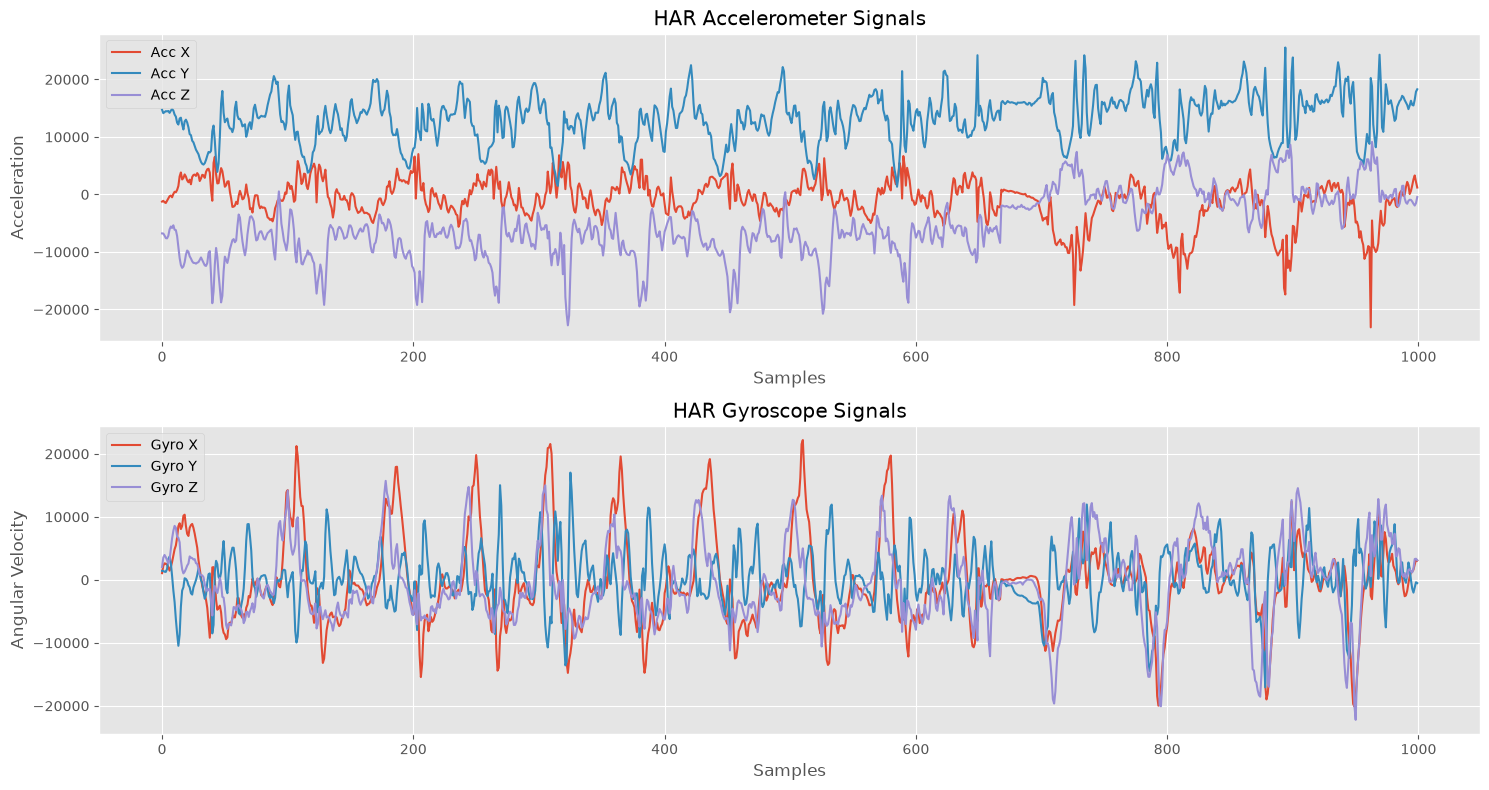

In [5]:
# ============================================================
# HAR Signal Exploration
# ============================================================

sample_window = har_df.iloc[:1000]

fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# Accelerometer
axes[0].plot(sample_window["ax"], label="Acc X")
axes[0].plot(sample_window["ay"], label="Acc Y")
axes[0].plot(sample_window["az"], label="Acc Z")

axes[0].set_title("HAR Accelerometer Signals")
axes[0].set_xlabel("Samples")
axes[0].set_ylabel("Acceleration")
axes[0].legend()
axes[0].grid(True)

# Gyroscope
axes[1].plot(sample_window["gx"], label="Gyro X")
axes[1].plot(sample_window["gy"], label="Gyro Y")
axes[1].plot(sample_window["gz"], label="Gyro Z")

axes[1].set_title("HAR Gyroscope Signals")
axes[1].set_xlabel("Samples")
axes[1].set_ylabel("Angular Velocity")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

,Activity,Samples
0,Walking Upstairs,2084
1,Walking Downstairs,2035
2,Walking,2863
3,Sitting,3619
4,Standing,2585
5,Jogging,2794


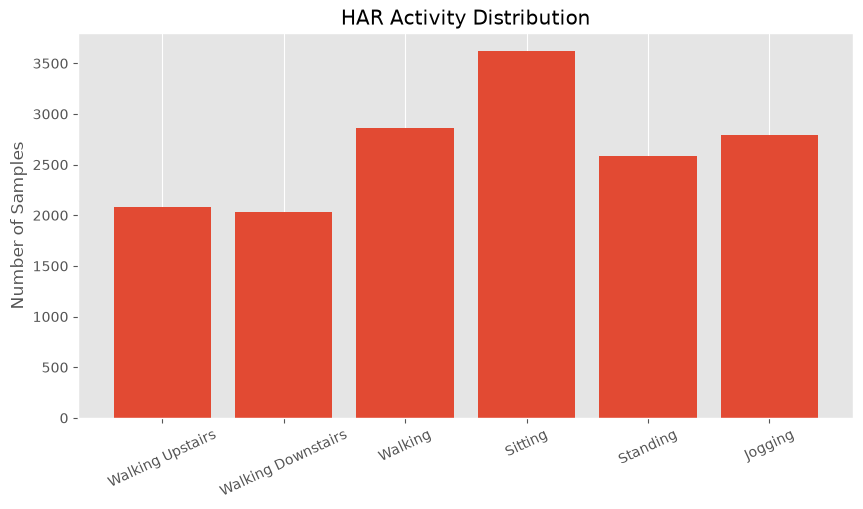

In [6]:
# ============================================================
# HAR Activity Distribution
# ============================================================

activity_map = {
    1: "Walking Upstairs",
    2: "Walking Downstairs",
    3: "Walking",
    4: "Sitting",
    5: "Standing",
    6: "Jogging"
}

activity_counts = har_df["activity"].value_counts().sort_index()

activity_df = pd.DataFrame({
    "Activity": [activity_map[i] for i in activity_counts.index],
    "Samples": activity_counts.values
})

display(activity_df)

plt.figure(figsize=(10,5))

plt.bar(activity_df["Activity"], activity_df["Samples"])

plt.xticks(rotation=25)
plt.ylabel("Number of Samples")
plt.title("HAR Activity Distribution")

plt.grid(axis="y")

plt.show()

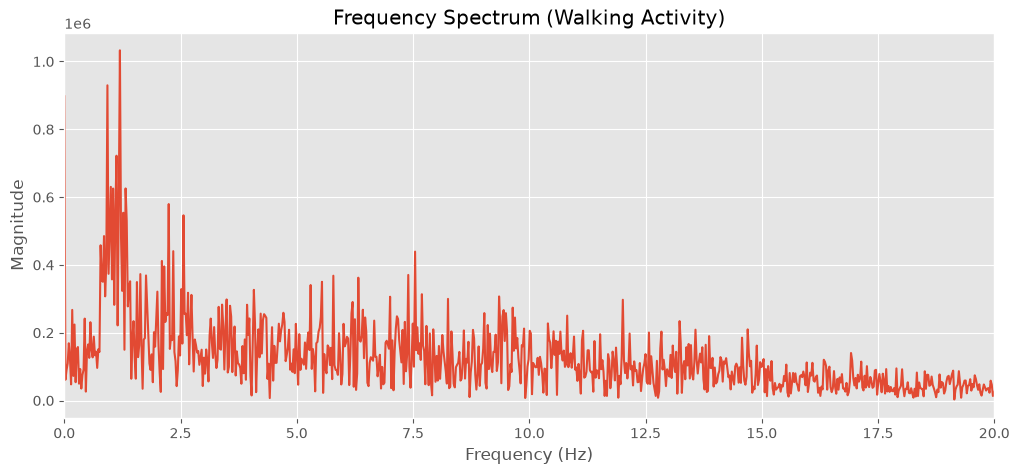

Estimated Dominant Frequency : 1.20 Hz


In [7]:
# ============================================================
# HAR Frequency Analysis
# ============================================================

from scipy.fft import fft, fftfreq

# ------------------------------------------------------------
# Select Walking Samples
# ------------------------------------------------------------

walking = har_df[har_df["activity"] == 3].iloc[:2048]

signal = walking["ax"].values

N = len(signal)

# Estimated sampling rate (dataset documentation does not specify)
fs = 50

freq = fftfreq(N, 1/fs)[:N//2]

fft_values = np.abs(fft(signal))[:N//2]

plt.figure(figsize=(12,5))

plt.plot(freq, fft_values)

plt.title("Frequency Spectrum (Walking Activity)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")

plt.grid(True)

plt.xlim(0,20)

plt.show()

dominant_frequency = freq[np.argmax(fft_values)]

print(f"Estimated Dominant Frequency : {dominant_frequency:.2f} Hz")

In [8]:
# ============================================================
# Cough Dataset Characterization
# ============================================================

import json

cough_root = COUGH_PATH / "Multimodal Cough Dataset"

subjects = sorted([d for d in cough_root.iterdir() if d.is_dir()])

accelerometer_files = list(cough_root.rglob("*Accelerometer.csv")) + list(cough_root.rglob("*accelerometer.csv"))
gyroscope_files = list(cough_root.rglob("*Gyroscope.csv")) + list(cough_root.rglob("*gyroscope.csv"))
magnetometer_files = list(cough_root.rglob("*Magnetometer.csv")) + list(cough_root.rglob("*magnetometer.csv"))

audio_files = list(cough_root.rglob("*.wav"))

sync_files = list(cough_root.rglob("sync_time.txt"))

annotation_file = cough_root / "DataAnnotation.json"

print("="*60)
print("COUGH DATASET INVENTORY")
print("="*60)

print(f"Subjects               : {len(subjects)}")
print(f"Accelerometer Files    : {len(accelerometer_files)}")
print(f"Gyroscope Files        : {len(gyroscope_files)}")
print(f"Magnetometer Files     : {len(magnetometer_files)}")
print(f"Audio Files            : {len(audio_files)}")
print(f"Synchronization Files  : {len(sync_files)}")
print(f"Annotation File Exists : {annotation_file.exists()}")

dataset_summary = pd.DataFrame({

    "Property":[
        "Subjects",
        "Trials per Subject",
        "Accelerometer",
        "Gyroscope",
        "Magnetometer",
        "Audio",
        "Annotations",
        "Sensor Type"
    ],

    "Value":[
        len(subjects),
        3,
        len(accelerometer_files),
        len(gyroscope_files),
        len(magnetometer_files),
        len(audio_files),
        "JSON",
        "Chest Mounted IMU"
    ]

})

display(dataset_summary)

COUGH DATASET INVENTORY
Subjects               : 13
Accelerometer Files    : 78
Gyroscope Files        : 78
Magnetometer Files     : 78
Audio Files            : 58
Synchronization Files  : 13
Annotation File Exists : True


,Property,Value
0,Subjects,13
1,Trials per Subject,3
2,Accelerometer,78
3,Gyroscope,78
4,Magnetometer,78
5,Audio,58
6,Annotations,JSON
7,Sensor Type,Chest Mounted IMU


Accelerometer Shape : (95123, 6)
Gyroscope Shape     : (95117, 6)
Magnetometer Shape  : (24231, 6)


,epoc (ms),timestamp (-0400),elapsed (s),x-axis (g),y-axis (g),z-axis (g)
0,1687879931619,2023-06-27T11.32.11.619,0.000,0.071,0.646,-0.625
1,1687879931629,2023-06-27T11.32.11.629,0.010,0.076,0.653,-0.633
2,1687879931639,2023-06-27T11.32.11.639,0.020,0.074,0.654,-0.623
3,1687879931648,2023-06-27T11.32.11.648,0.029,0.069,0.657,-0.613
4,1687879931658,2023-06-27T11.32.11.658,0.039,0.067,0.657,-0.609


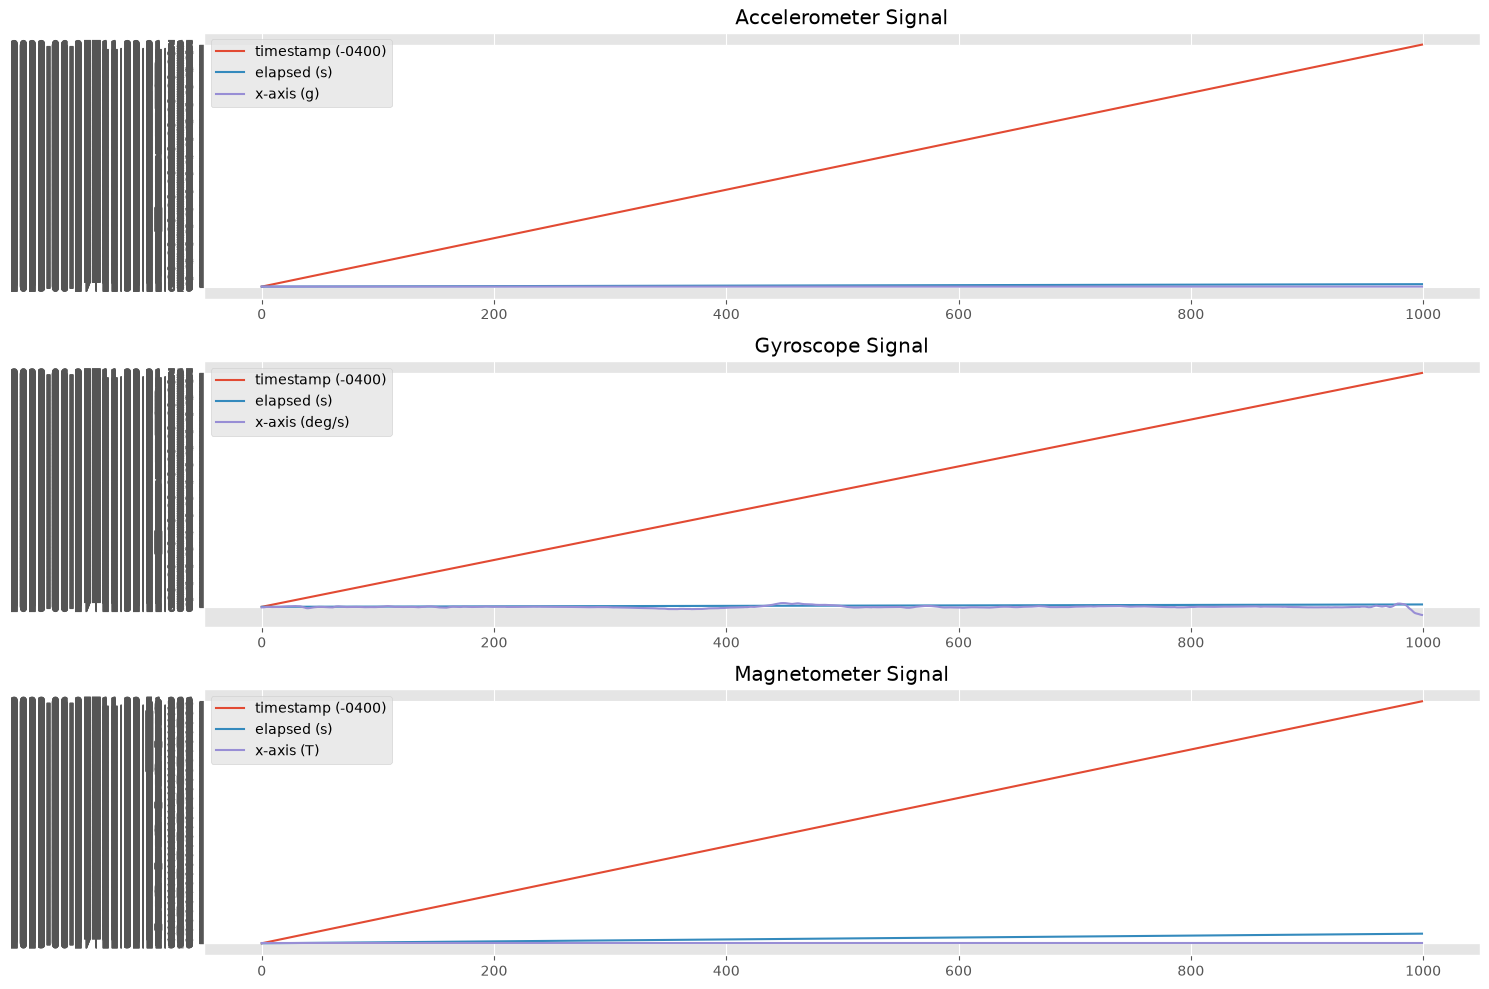

In [9]:
# ============================================================
# Cough Signal Exploration
# ============================================================

sample_acc = accelerometer_files[0]
sample_gyro = gyroscope_files[0]
sample_mag = magnetometer_files[0]

acc = pd.read_csv(sample_acc)
gyro = pd.read_csv(sample_gyro)
mag = pd.read_csv(sample_mag)

print("Accelerometer Shape :", acc.shape)
print("Gyroscope Shape     :", gyro.shape)
print("Magnetometer Shape  :", mag.shape)

display(acc.head())

fig, axes = plt.subplots(3,1,figsize=(15,10))

# ------------------------------------------------------------
# Accelerometer
# ------------------------------------------------------------

for col in acc.columns[1:4]:

    axes[0].plot(acc[col].iloc[:1000], label=col)

axes[0].set_title("Accelerometer Signal")
axes[0].legend()
axes[0].grid(True)

# ------------------------------------------------------------
# Gyroscope
# ------------------------------------------------------------

for col in gyro.columns[1:4]:

    axes[1].plot(gyro[col].iloc[:1000], label=col)

axes[1].set_title("Gyroscope Signal")
axes[1].legend()
axes[1].grid(True)

# ------------------------------------------------------------
# Magnetometer
# ------------------------------------------------------------

for col in mag.columns[1:4]:

    axes[2].plot(mag[col].iloc[:1000], label=col)

axes[2].set_title("Magnetometer Signal")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# Cough Dataset Frequency Analysis
# ============================================================

def estimate_sampling_rate(df):

    """
    Attempt to estimate sampling frequency from a timestamp
    column if one exists.
    """

    timestamp_candidates = [
        col for col in df.columns
        if any(
            key in str(col).lower()
            for key in [
                "time",
                "timestamp",
                "elapsed"
            ]
        )
    ]

    if not timestamp_candidates:
        return None, None

    for col in timestamp_candidates:

        values = pd.to_numeric(
            df[col],
            errors="coerce"
        ).dropna().values

        if len(values) < 3:
            continue

        differences = np.diff(values)

        differences = differences[
            differences > 0
        ]

        if len(differences) == 0:
            continue

        median_dt = np.median(
            differences
        )

        # Try seconds
        if median_dt < 1:
            fs = 1 / median_dt
            unit = "seconds"

        # Try milliseconds
        else:
            fs = 1000 / median_dt
            unit = "milliseconds"

        return fs, col

    return None, None


# ------------------------------------------------------------
# Estimate sampling rate
# ------------------------------------------------------------

acc_fs, acc_time_col = estimate_sampling_rate(acc)

gyro_fs, gyro_time_col = estimate_sampling_rate(gyro)

mag_fs, mag_time_col = estimate_sampling_rate(mag)


print("=" * 70)
print("COUGH DATASET SAMPLING RATE ANALYSIS")
print("=" * 70)

print(
    f"Accelerometer sampling rate : "
    f"{acc_fs if acc_fs else 'Not detected'} Hz"
)

print(
    f"Gyroscope sampling rate     : "
    f"{gyro_fs if gyro_fs else 'Not detected'} Hz"
)

print(
    f"Magnetometer sampling rate  : "
    f"{mag_fs if mag_fs else 'Not detected'} Hz"
)

In [ ]:
# ============================================================
# Cough Dataset IMU Frequency Spectrum
# ============================================================

def plot_fft(
    df,
    fs,
    sensor_name,
    max_frequency=40
):

    if fs is None:

        print(
            f"{sensor_name}: "
            "Sampling rate unavailable. "
            "Skipping absolute-frequency FFT."
        )

        return

    numeric_columns = [
        col for col in df.columns
        if pd.api.types.is_numeric_dtype(
            df[col]
        )
    ]

    # Remove timestamp-like columns
    signal_columns = [
        col for col in numeric_columns
        if not any(
            key in str(col).lower()
            for key in [
                "time",
                "timestamp",
                "elapsed"
            ]
        )
    ]

    signal_columns = signal_columns[:3]

    fig, axes = plt.subplots(
        len(signal_columns),
        1,
        figsize=(12, 4 * len(signal_columns))
    )

    if len(signal_columns) == 1:
        axes = [axes]

    for ax, column in zip(
        axes,
        signal_columns
    ):

        signal = pd.to_numeric(
            df[column],
            errors="coerce"
        ).dropna().values

        if len(signal) < 32:
            continue

        # Limit computation
        signal = signal[:8192]

        N = len(signal)

        # Remove DC component
        signal = signal - np.mean(signal)

        spectrum = np.abs(
            np.fft.fft(np.asarray(signal, dtype=float))
        )[:N // 2]

        frequencies = fftfreq(
            N,
            d=1 / fs
        )[:N // 2]

        ax.plot(
            frequencies,
            spectrum
        )

        ax.set_title(
            f"{sensor_name} - {column}"
        )

        ax.set_xlabel(
            "Frequency (Hz)"
        )

        ax.set_ylabel(
            "Magnitude"
        )

        ax.set_xlim(
            0,
            min(
                max_frequency,
                fs / 2
            )
        )

        ax.grid(True)

    plt.tight_layout()
    plt.show()


plot_fft(
    acc,
    acc_fs,
    "Accelerometer"
)

plot_fft(
    gyro,
    gyro_fs,
    "Gyroscope"
)

plot_fft(
    mag,
    mag_fs,
    "Magnetometer"
)

In [10]:
# ============================================================
# Cough Event Analysis
# ============================================================

with open(annotation_file, "r", encoding="utf-8") as f:
    annotations = json.load(f)

print("=" * 70)
print("COUGH DATASET ANNOTATION ANALYSIS")
print("=" * 70)

print(f"Top-level Type : {type(annotations).__name__}")

if isinstance(annotations, list):
    print(f"Number of Top-level Records : {len(annotations)}")

elif isinstance(annotations, dict):
    print("Top-level Keys:")
    print(list(annotations.keys()))

else:
    raise TypeError(
        f"Unsupported JSON structure: {type(annotations).__name__}"
    )


# ============================================================
# Inspect JSON Structure
# ============================================================

print("\n" + "=" * 70)
print("FIRST RECORD STRUCTURE")
print("=" * 70)

if isinstance(annotations, list) and len(annotations) > 0:

    first_record = annotations[0]

    print("Record type:", type(first_record).__name__)

    if isinstance(first_record, dict):
        print("\nKeys in first record:")
        print(list(first_record.keys()))

        print("\nFirst record:")
        print(first_record)

elif isinstance(annotations, dict):

    print(annotations)


# ============================================================
# Recursive Key Discovery
# ============================================================

key_values = {}


def collect_keys(obj):

    if isinstance(obj, dict):

        for key, value in obj.items():

            key_str = str(key)

            if key_str not in key_values:
                key_values[key_str] = []

            # Store a few example values
            if len(key_values[key_str]) < 5:
                key_values[key_str].append(value)

            collect_keys(value)

    elif isinstance(obj, list):

        for item in obj:
            collect_keys(item)


collect_keys(annotations)


print("\n" + "=" * 70)
print("ALL JSON KEYS DISCOVERED")
print("=" * 70)

for key in sorted(key_values.keys()):

    print(f"\nKEY: {key}")

    examples = key_values[key]

    for example in examples[:3]:

        if isinstance(example, (dict, list)):
            print("  ", type(example).__name__)

        else:
            print("  ", repr(example)[:200])


# ============================================================
# Candidate Annotation Values
# ============================================================

candidate_keywords = [
    "label",
    "class",
    "event",
    "sound",
    "annotation",
    "category",
    "type",
    "name"
]

candidate_values = []


def find_candidate_values(obj):

    if isinstance(obj, dict):

        for key, value in obj.items():

            key_lower = str(key).lower()

            if any(keyword in key_lower for keyword in candidate_keywords):

                if isinstance(value, (str, int, float)):

                    candidate_values.append(
                        (str(key), value)
                    )

            find_candidate_values(value)

    elif isinstance(obj, list):

        for item in obj:

            find_candidate_values(item)


find_candidate_values(annotations)


print("\n" + "=" * 70)
print("CANDIDATE ANNOTATION VALUES")
print("=" * 70)

if candidate_values:

    candidate_df = pd.DataFrame(
        candidate_values,
        columns=["Key", "Value"]
    )

    display(candidate_df.head(100))

else:

    print("No candidate annotation fields were detected.")

COUGH DATASET ANNOTATION ANALYSIS
Top-level Type : list
Number of Top-level Records : 39

FIRST RECORD STRUCTURE
Record type: dict

Keys in first record:
['assigned_user', 'created_at', 'filename', 'is_marked_for_review', 'last_modified', 'original_filename', 'reference_transcription', 'segmentations', 'url']

First record:
{'assigned_user': {'id': 3, 'role': 'admin', 'username': 'ychen239'}, 'created_at': 'Mon, 06 Nov 2023 21:27:29 GMT', 'filename': '2412d29e8da0442c9374dca64fb613f5.wav', 'is_marked_for_review': False, 'last_modified': 'Tue, 14 Nov 2023 19:04:32 GMT', 'original_filename': '005_no_talking_in.wav', 'reference_transcription': None, 'segmentations': [{'annotations': {'Cough': {'id': 1, 'values': {'id': 1, 'value': '0'}}}, 'created_at': 'Mon, 13 Nov 2023 00:32:00 GMT', 'end_time': 228.366, 'last_modified': 'Mon, 13 Nov 2023 00:32:00 GMT', 'start_time': 228.016, 'transcription': None}, {'annotations': {'Other Sound': {'id': 9, 'values': {'id': 8, 'value': '8'}}}, 'created_a

,Key,Value
0,username,ychen239
1,filename,2412d29e8da0442c9374dca64fb613f5.wav
2,original_filename,005_no_talking_in.wav
3,username,ychen239
4,filename,6333ec45deb04cca9762b4a2d9549401.wav
5,original_filename,006_No_Talking_Out.wav
6,username,ychen239
7,filename,e75c563079b240998ff6c4cfea4df44a.wav
8,original_filename,006_Talking_In.wav
9,username,ychen239


In [ ]:
# ============================================================
# Frequency-Band Energy Analysis
# ============================================================

ANALYSIS_BANDS = [
    ("0–1 Hz", 0, 1),
    ("1–2 Hz", 1, 2),
    ("2–5 Hz", 2, 5),
    ("5–10 Hz", 5, 10),
    ("10–20 Hz", 10, 20),
    ("20–30 Hz", 20, 30),
    (">30 Hz", 30, np.inf)
]


def calculate_band_energy(
    signal,
    fs,
    bands
):

    signal = np.asarray(
        signal,
        dtype=float
    )

    signal = signal[
        np.isfinite(signal)
    ]

    if len(signal) < 32:
        return None

    signal = signal - np.mean(signal)

    N = len(signal)

    spectrum = np.abs(
        np.fft.fft(
            np.asarray(signal, dtype=float)
        )
    )[:N // 2]

    frequencies = fftfreq(
        N,
        d=1 / fs
    )[:N // 2]

    power = spectrum ** 2

    total_energy = np.sum(power)

    results = []

    nyquist = fs / 2

    for band_name, low, high in bands:

        upper = min(
            high,
            nyquist
        )

        if low >= nyquist:
            energy = 0

        else:

            mask = (
                (frequencies >= low) &
                (frequencies < upper)
            )

            energy = np.sum(
                power[mask]
            )

        percentage = (
            100 * energy / total_energy
            if total_energy > 0
            else 0
        )

        results.append({

            "Frequency Band": band_name,

            "Energy": energy,

            "Energy (%)": percentage

        })

    return pd.DataFrame(results)


# ------------------------------------------------------------
# Accelerometer Band Energy
# ------------------------------------------------------------

if acc_fs is not None:

    acc_signal = acc.iloc[:, 1].values

    acc_band_energy = calculate_band_energy(
        acc_signal,
        acc_fs,
        ANALYSIS_BANDS
    )

    print("=" * 70)
    print("ACCELEROMETER FREQUENCY-BAND ENERGY")
    print("=" * 70)

    display(
        acc_band_energy
    )

In [11]:
# ============================================================
# Cross Dataset Comparison
# ============================================================

comparison = pd.DataFrame({

    "Feature":[
        "Primary Purpose",
        "Subjects",
        "Activities / Events",
        "Accelerometer",
        "Gyroscope",
        "Magnetometer",
        "Audio",
        "Chest Mounted",
        "Activity Labels",
        "Multi-modal",
        "Suitable for Artifact Learning"
    ],

    "HAR Dataset":[
        "Human Activity Recognition",
        "Unknown",
        "6 Activities",
        "✓",
        "✓",
        "✗",
        "✗",
        "Unknown",
        "✓",
        "✗",
        "✓"
    ],

    "Multimodal Cough Dataset":[
        "Respiratory Artifact Detection",
        "13",
        "Cough, Speech, Laugh, Breath, etc.",
        "✓",
        "✓",
        "✓",
        "✓",
        "✓",
        "✓",
        "✓",
        "✓"
    ]

})

display(comparison)

,Feature,HAR Dataset,Multimodal Cough Dataset
0,Primary Purpose,Human Activity Recognition,Respiratory Artifact Detection
1,Subjects,Unknown,13
2,Activities / Events,6 Activities,"Cough, Speech, Laugh, Breath, etc."
3,Accelerometer,✓,✓
4,Gyroscope,✓,✓
5,Magnetometer,✗,✓
6,Audio,✗,✓
7,Chest Mounted,Unknown,✓
8,Activity Labels,✓,✓
9,Multi-modal,✗,✓


In [12]:
# ============================================================
# Unified Artifact Library
# ============================================================

artifact_library = pd.DataFrame({

    "Artifact":[
        "Walking",
        "Walking Upstairs",
        "Walking Downstairs",
        "Standing",
        "Sitting",
        "Jogging",
        "Body Motion",
        "Speech",
        "Laugh",
        "Deep Breath",
        "Cough",
        "Groan",
        "Sneeze",
        "Transition Movements"
    ],

    "Dataset Source":[
        "HAR",
        "HAR",
        "HAR",
        "HAR",
        "HAR",
        "HAR",
        "Both",
        "Cough Dataset",
        "Cough Dataset",
        "Cough Dataset",
        "Cough Dataset",
        "Cough Dataset",
        "Cough Dataset",
        "Both"
    ],

    "Future Role":[
        "Maternal Motion Artifact",
        "Maternal Motion Artifact",
        "Maternal Motion Artifact",
        "Posture Artifact",
        "Posture Artifact",
        "High Intensity Motion",
        "General Motion Artifact",
        "Respiratory Artifact",
        "Respiratory Artifact",
        "Respiratory Artifact",
        "Respiratory Artifact",
        "Respiratory Artifact",
        "Respiratory Artifact",
        "Motion Transition Artifact"
    ]

})

display(artifact_library)

,Artifact,Dataset Source,Future Role
0,Walking,HAR,Maternal Motion Artifact
1,Walking Upstairs,HAR,Maternal Motion Artifact
2,Walking Downstairs,HAR,Maternal Motion Artifact
3,Standing,HAR,Posture Artifact
4,Sitting,HAR,Posture Artifact
5,Jogging,HAR,High Intensity Motion
6,Body Motion,Both,General Motion Artifact
7,Speech,Cough Dataset,Respiratory Artifact
8,Laugh,Cough Dataset,Respiratory Artifact
9,Deep Breath,Cough Dataset,Respiratory Artifact


In [13]:
# ============================================================
# Final Conclusions
# ============================================================

summary = pd.DataFrame({

    "Question":[
        "Why use the HAR dataset?",
        "Why use the Cough dataset?",
        "Main contribution of HAR",
        "Main contribution of Cough",
        "Can these datasets replace pregnancy data?",
        "Will they improve artifact modelling?",
        "Future replacement?",
        "Role in our software pipeline"
    ],

    "Answer":[
        "Provides labelled whole-body motion artifacts.",
        "Provides chest-mounted respiratory and body motion artifacts.",
        "Walking, sitting, standing, jogging and posture changes.",
        "Cough, speech, laugh, breathing and chest motion artifacts.",
        "No. They complement fetal datasets but cannot replace them.",
        "Yes. They allow learning common maternal artifact signatures.",
        "Yes. They will later be replaced with IMU recordings collected from pregnant mothers using our STM32 wearable.",
        "They form the artifact library used before fetal movement behaviour analysis."
    ]

})

display(summary)

print("="*80)
print("FINAL CONCLUSION")
print("="*80)

print("""
This notebook systematically characterized two publicly available
artifact datasets before their integration into the fetal movement
analysis pipeline.

The HAR dataset contributes general maternal motion artifacts such as
walking, sitting, standing, jogging and posture transitions.

The Multimodal Cough dataset contributes chest-mounted respiratory
artifacts including cough, speech, laugh, deep breathing and other
non-fetal body movements.

Together these datasets form an initial artifact library that will
support the development of a unified artifact rejection module.

In the final system these public datasets will be complemented and
eventually replaced by recordings collected from our own STM32-based
maternal wearable prototype, creating a pregnancy-specific artifact
database for behavioral fetal movement analysis.
""")  

,Question,Answer
0,Why use the HAR dataset?,Provides labelled whole-body motion artifacts.
1,Why use the Cough dataset?,Provides chest-mounted respiratory and body mo...
2,Main contribution of HAR,"Walking, sitting, standing, jogging and postur..."
3,Main contribution of Cough,"Cough, speech, laugh, breathing and chest moti..."
4,Can these datasets replace pregnancy data?,No. They complement fetal datasets but cannot ...
5,Will they improve artifact modelling?,Yes. They allow learning common maternal artif...
6,Future replacement?,Yes. They will later be replaced with IMU reco...
7,Role in our software pipeline,They form the artifact library used before fet...


FINAL CONCLUSION

This notebook systematically characterized two publicly available
artifact datasets before their integration into the fetal movement
analysis pipeline.

The HAR dataset contributes general maternal motion artifacts such as
walking, sitting, standing, jogging and posture transitions.

The Multimodal Cough dataset contributes chest-mounted respiratory
artifacts including cough, speech, laugh, deep breathing and other
non-fetal body movements.

Together these datasets form an initial artifact library that will
support the development of a unified artifact rejection module.

In the final system these public datasets will be complemented and
eventually replaced by recordings collected from our own STM32-based
maternal wearable prototype, creating a pregnancy-specific artifact
database for behavioral fetal movement analysis.

